In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from sympy import Matrix
import sympy as sym

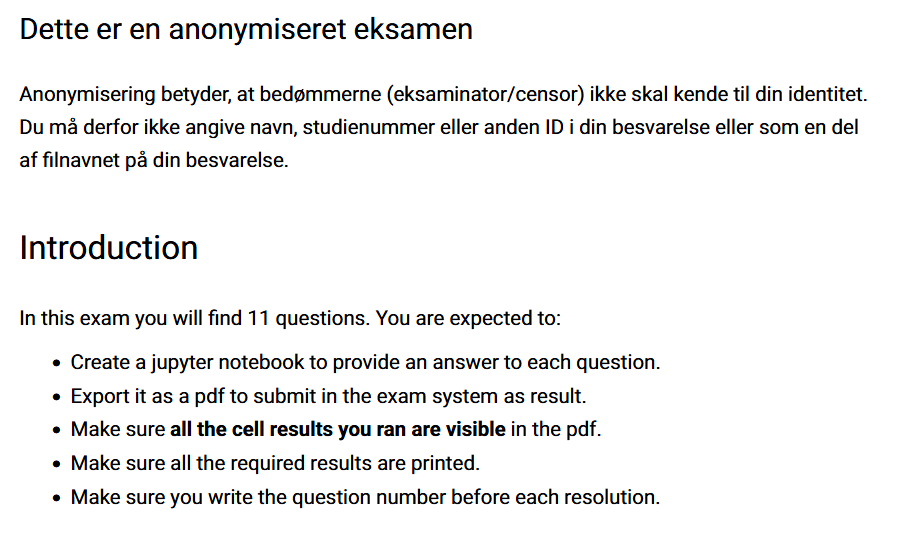

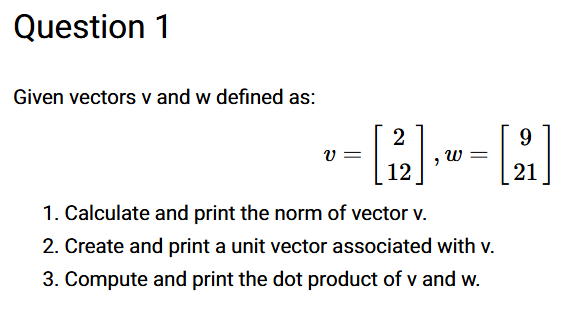

In [6]:
v = np.array ([[2],[12]])
w = np.array ([[9], [21]])

#1
normv = np.linalg.norm(v)
print("Norm v: ",normv)

#2
unit_vector_v=(v/normv)
print("The unit vector is: ",'\n', unit_vector_v)

#3
dot_prod = v.flatten() @ w.flatten()
print ("Dot product: ",dot_prod)

Norm v:  12.165525060596439
The unit vector is:  
 [[0.16439899]
 [0.98639392]]
Dot product:  270


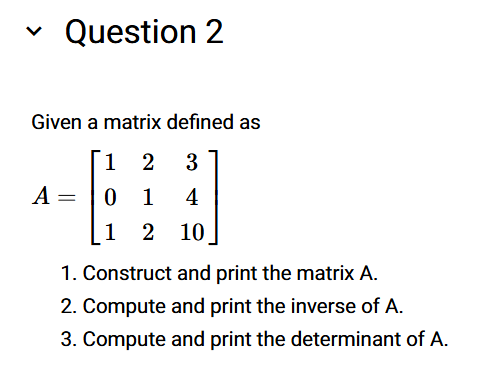

In [14]:
A = np.array ([[1, 2, 3],
               [0, 1, 4],
               [1, 2, 10]])

#1
print (A)

#2
A_inv = np.linalg.inv(A)
print ("A_inv: \n", A_inv)
#verification
I = A @ A_inv
print ("Should give us the identity matrix: \n", np.round(I,2))

#3:
A_det = np.linalg.det(A)
print ("A det: ", np.round(A_det,4))


[[ 1  2  3]
 [ 0  1  4]
 [ 1  2 10]]
A_inv: 
 [[ 0.28571429 -2.          0.71428571]
 [ 0.57142857  1.         -0.57142857]
 [-0.14285714  0.          0.14285714]]
Should give us the identity matrix: 
 [[ 1.  0. -0.]
 [ 0.  1.  0.]
 [ 0.  0.  1.]]
A det:  7.0


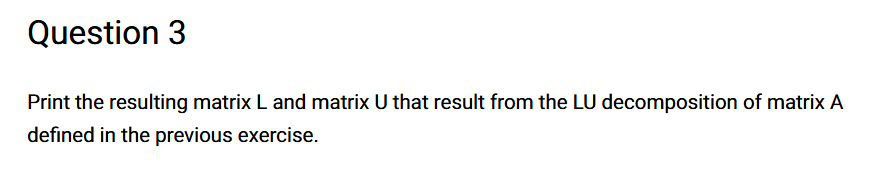

In [15]:
P, L, U = scipy.linalg.lu(A)

print ("L: \n", L)
print ("U: \n", U)

L: 
 [[1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 1.]]
U: 
 [[1. 2. 3.]
 [0. 1. 4.]
 [0. 0. 7.]]


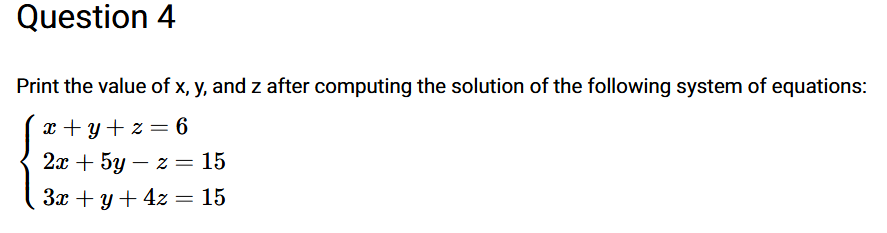

In [17]:
A1 = np.array ([[1, 1, 1],
                [2, 5, -1],
                [3, 1, 4]])
b1 = np.array([[6], [15], [15]])

x = np.linalg.solve(A1,b1)
print ("x = ",np.round(x[0],2))
print ("y = ",np.round(x[1],2))
print ("z = ",np.round(x[2],2), '\n')

x =  [3.]
y =  [2.]
z =  [1.] 



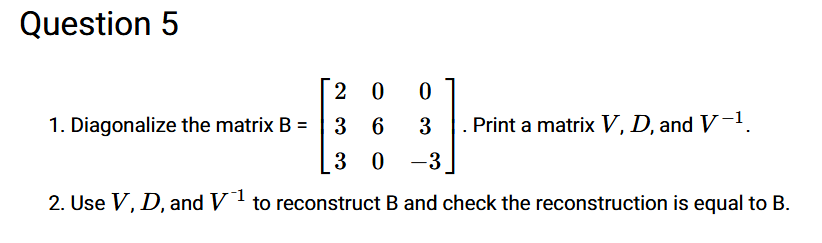

In [18]:
B = np.array ([[2, 0, 0],
               [3, 6, 3],
               [3, 0, -3]])

#1 Diagonalize the matrix
eigenvalues, V = np.linalg.eig(B)
D   = np.diag(eigenvalues)
V_inv = np.linalg.inv(V)
print ("V: \n", np.round(V,4), "\nD: \n", np.round(D,4), "\nV^-1: \n", np.round(V_inv,4), '\n')

#Reconstruct using V, D and V_inv:
B_rec = V @ D @ V_inv
print ("Reconstruction (V @ D @ V_inv): \n", B_rec)
print ("The matrix B: \n", B, '\n')

V: 
 [[ 0.      0.      0.5976]
 [ 1.     -0.3162 -0.7171]
 [ 0.      0.9487  0.3586]] 
D: 
 [[ 6.  0.  0.]
 [ 0. -3.  0.]
 [ 0.  0.  2.]] 
V^-1: 
 [[ 1.      1.      0.3333]
 [-0.6325  0.      1.0541]
 [ 1.6733  0.      0.    ]] 

Reconstruction (V @ D @ V_inv): 
 [[ 2.  0.  0.]
 [ 3.  6.  3.]
 [ 3.  0. -3.]]
The matrix B: 
 [[ 2  0  0]
 [ 3  6  3]
 [ 3  0 -3]] 



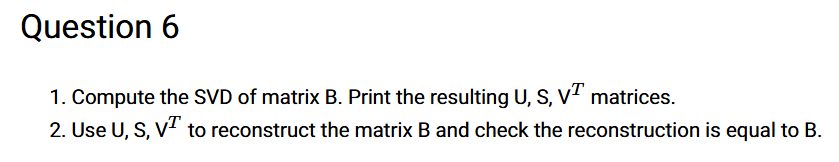

In [21]:
#1 compute the SVD of matrix B
U, S, Vt = np.linalg.svd(B)
#First we convert S from a 1D array to a diagonal matrix:
S_matrix = np.diag(S)
print ("U: \n", np.round(U,4), "\nS: \n", np.round (S_matrix,4), "\n Vt: \n", np.round(Vt,4), '\n')

# 2. Reconstruct and verify

#Now we reconstruct B:
B_verify = U @ S_matrix @ Vt
print ("B: \n", B , '\n')
print ("Verification (U @ S (matrix form) @ Vt) \n", np.round(B_verify,2), '\n')


U: 
 [[-0.1197  0.3295 -0.9365]
 [-0.9926 -0.0583  0.1064]
 [-0.0196  0.9424  0.334 ]] 
S: 
 [[7.3975 0.     0.    ]
 [0.     4.4831 0.    ]
 [0.     0.     1.0855]] 
 Vt: 
 [[-0.4428 -0.8051 -0.3946]
 [ 0.7386 -0.078  -0.6696]
 [-0.5083  0.588  -0.6292]] 

B: 
 [[ 2  0  0]
 [ 3  6  3]
 [ 3  0 -3]] 

Verification (U @ S (matrix form) @ Vt) 
 [[ 2.  0. -0.]
 [ 3.  6.  3.]
 [ 3. -0. -3.]] 



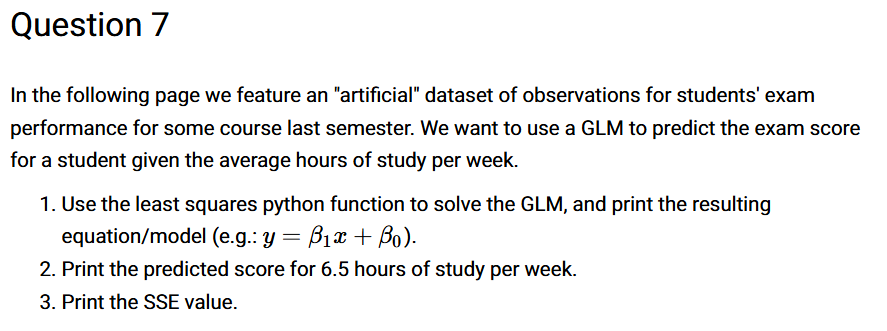

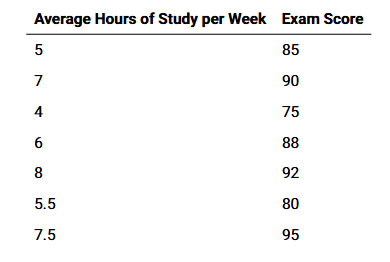

In [24]:
hours  = np.array([5, 7, 4, 6, 8, 5.5, 7.5], dtype=float)
scores = np.array([85, 90, 75, 88, 92, 80, 95], dtype=float)

# Design matrix: [x, 1]
X = np.column_stack([hours, np.ones(len(hours))])

# Solve
beta, _, _, _ = np.linalg.lstsq(X, scores, rcond=None)
beta1, beta0  = beta
print(f"Model: y = {beta1:.4f}*x + {beta0:.4f}")

# Predict
y_hat = X @ beta
pred  = beta1 * 6.5 + beta0
print(f"Prediction at x=6.5: {pred:.2f}")

# SSE and R²
SSE    = np.sum((scores - y_hat)**2)
print ("SSE: ", np.round(SSE,4))

Model: y = 4.4566*x + 59.0520
Prediction at x=6.5: 88.02
SSE:  48.2803


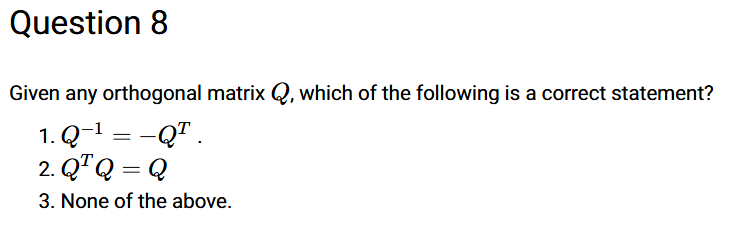

The correct statement is $Q^T Q = I$ — transpose equals inverse


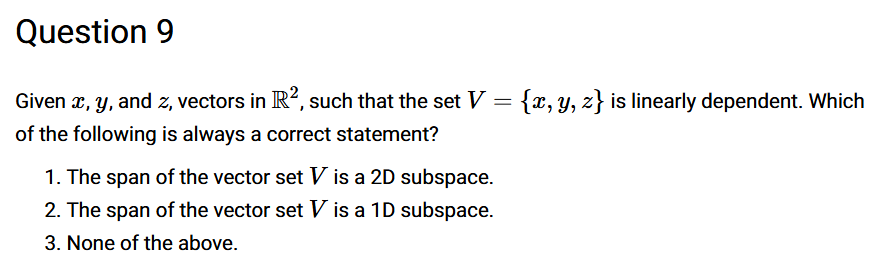

Since both it is possible that the vector set V can either be a 2D or a 1D subspace, the answer is none of the above. The only thing that we know is, that when a vector set is linearly dependent, at least one vector is redundant.

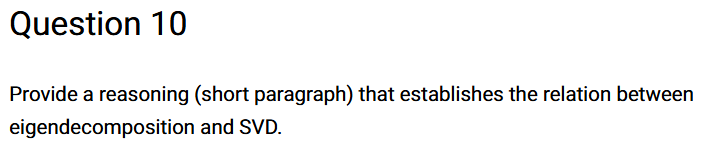

SVD is related to eigendecomposition through the matrices $AA^T$ and $A^TA$.

- The left singular vectors $U$ are the eigenvectors of $AA^T$
- The right singular vectors $V$ are the eigenvectors of $A^TA$
- The singular values are $s_i = \sqrt{\lambda_i}$, where $\lambda_i$ are 
  the eigenvalues of $AA^T$ (or equivalently $A^TA$)

SVD is therefore a generalisation of eigendecomposition to all matrices — 
not just square ones.

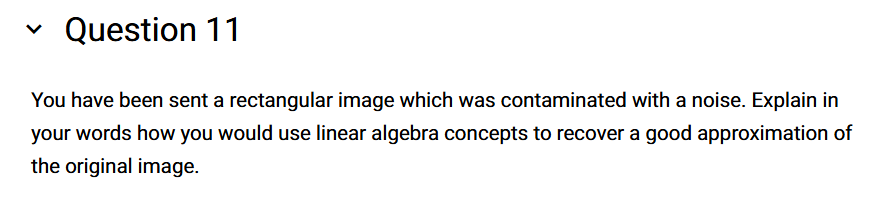
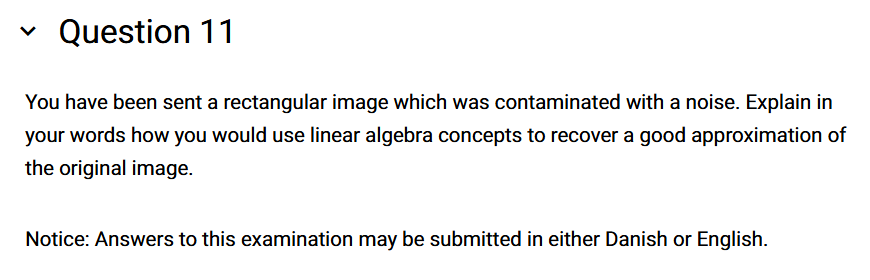

To recover a good approximation of the original image, we can use SVD 
and low-rank approximation:

1. Represent the image as a matrix $A$
2. Compute the SVD: $A = U\Sigma V^T$
3. Keep only the $k$ largest singular values and discard the rest:

$$\hat{A}_k = \sum_{i=1}^{k} s_i \cdot u_i \cdot v_i^T$$

The large singular values capture the important structure of the image, 
while the small ones correspond to noise. By discarding the smallest 
singular values, we recover a clean approximation of the original image.